# AI for Communication and Marketing. Lab Exam Part 2
## Customer Churn

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    recall_score, precision_score, roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


---
# Task A. Data Audit & Quality



## A.1 Load the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/data.xlsx', sheet_name='E Comm')
print(f"Shape: {df.shape}")
df.head()


Mounted at /content/drive
Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001.0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002.0,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003.0,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004.0,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005.0,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5628 non-null   float64
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5628 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Variable inventory

| Variable | Role | Type |
|---|---|---|
| `CustomerID` | Identifier | Numeric |
| `Churn` | Target | Binary (0/1) |
| `Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `NumberOfDeviceRegistered`, `NumberOfAddress`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`, `CashbackAmount` | Numeric features | Numeric |
| `CityTier`, `SatisfactionScore`, `Complain` | Ordinal / binary features | Numeric (treated as categorical when sensible) |
| `PreferredLoginDevice`, `PreferredPaymentMode`, `Gender`, `PreferedOrderCat`, `MaritalStatus` | Categorical features | String |

There are no datetime fields. `CustomerID` will be dropped before modeling since it carries no predictive signal.


## A.2 Missing values, duplicates and basic consistency checks

In [4]:
missing = pd.DataFrame({
    'missing': df.isnull().sum(),
    'pct': (df.isnull().mean() * 100).round(2)
})
missing = missing[missing['missing'] > 0].sort_values('missing', ascending=False)
missing


,missing,pct
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46
CustomerID,2,0.04
Gender,2,0.04


In [5]:
print(f"Full-row duplicates: {df.duplicated().sum()}")
print(f"Rows with missing CustomerID: {df['CustomerID'].isnull().sum()}")
print(f"Duplicate CustomerIDs (NaN included): {df['CustomerID'].duplicated().sum()}")
print(f"Duplicate CustomerIDs (NaN excluded): {df['CustomerID'].dropna().duplicated().sum()}")


Full-row duplicates: 0
Rows with missing CustomerID: 2
Duplicate CustomerIDs (NaN included): 1
Duplicate CustomerIDs (NaN excluded): 0


**Findings.**

- Nine columns contain missing values, seven between 4% and 5% of the rows - well below the 5% rule of thumb that would justify listwise deletion of features, but high enough that we should impute rather than drop rows.
- Two rows have a missing `CustomerID`. Since the identifier is the row key and only 2 rows are affected, we drop them.
- No full-row duplicates.


In [6]:
df = df.dropna(subset=['CustomerID']).copy()
df['CustomerID'] = df['CustomerID'].astype(int)
print(f"Shape after dropping rows with missing CustomerID: {df.shape}")
print(f"Duplicate CustomerIDs remaining: {df['CustomerID'].duplicated().sum()}")


Shape after dropping rows with missing CustomerID: (5628, 20)
Duplicate CustomerIDs remaining: 0


## A.3 Consistency of categorical variables

A quick look at the unique values reveals that the same concept is encoded under different labels. These need to be unified before any analysis or encoding.


In [7]:
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'MaritalStatus']
for c in cat_cols:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False))



PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2763
Computer        1631
Phone           1229
N.A.               5
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2313
Credit Card         1500
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender:
Gender
Male      3382
Female    2244
NaN          2
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2049
Mobile Phone          1270
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2982
Single      1795
Divorced     848
Widow          3
Name: count, dtype: int64


**Inconsistencies**

- `PreferredLoginDevice`: `Mobile Phone` and `Phone` are the same device family; `N.A.` is a textual placeholder for a missing value.
- `PreferredPaymentMode`: `CC` is the abbreviation of `Credit Card`; `COD` is the abbreviation of `Cash on Delivery`.
- `PreferedOrderCat`: `Mobile` and `Mobile Phone` refer to the same category.


In [8]:
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone',
    'N.A.': np.nan
})

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
    'Mobile': 'Mobile Phone'
})

for c in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(f"{c}: {sorted(df[c].dropna().unique().tolist())}")


PreferredLoginDevice: ['Computer', 'Mobile Phone']
PreferredPaymentMode: ['Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']
PreferedOrderCat: ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile Phone', 'Others']


After this step `PreferredLoginDevice` shows 5 additional missing values (the rows formerly coded as `N.A.`), which will be handled together with the other missing categoricals below.


## A.4 Outlier detection


In [9]:
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
            'NumberOfDeviceRegistered', 'NumberOfAddress',
            'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
            'DaySinceLastOrder', 'CashbackAmount']
df[num_cols].describe().T[['min', '25%', '50%', '75%', 'max', 'mean', 'std']].round(2)


,min,25%,50%,75%,max,mean,std
Tenure,0.0,2.00,9.00,16.00,61.0,10.19,8.56
WarehouseToHome,5.0,9.00,14.00,20.00,127.0,15.64,8.53
HourSpendOnApp,0.0,2.00,3.00,3.00,5.0,2.93,0.72
NumberOfDeviceRegistered,1.0,3.00,4.00,4.00,6.0,3.69,1.02
NumberOfAddress,1.0,2.00,3.00,6.00,22.0,4.21,2.58
OrderAmountHikeFromlastYear,11.0,13.00,15.00,18.00,26.0,15.71,3.68
CouponUsed,0.0,1.00,1.00,2.00,16.0,1.75,1.89
OrderCount,1.0,1.00,2.00,3.00,16.0,3.01,2.94
DaySinceLastOrder,0.0,2.00,3.00,7.00,46.0,4.54,3.65
CashbackAmount,0.0,145.77,163.33,196.43,999999.0,532.53,18846.18


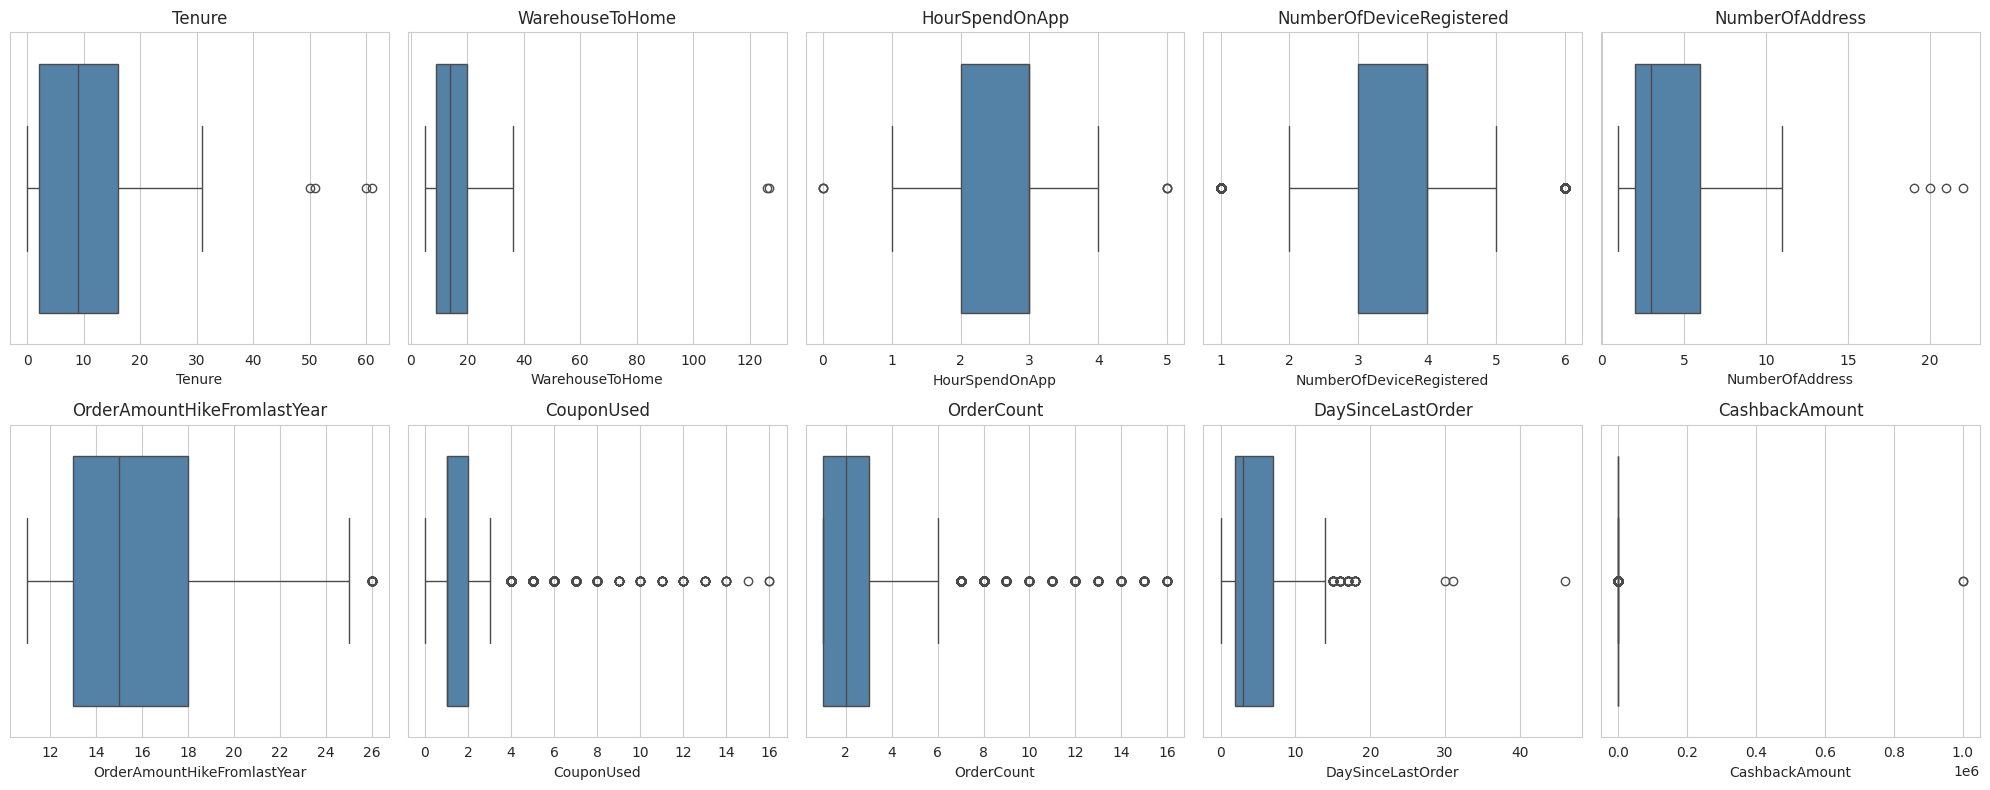

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Findings on outliers.**

- `CashbackAmount` has a maximum of **999,999** while the 75th percentile sits at 196. These observations must be cleaned.
- `WarehouseToHome` has two values at 126 and 127 km while the rest of the distribution caps at 36 km. The values are physically implausible for an e-commerce last-mile distance and look like typos.
- `Tenure` ranges from 0 to 61 months. Even high valus remain plausible values (about 5 years of relationship).
- `DaySinceLastOrder` has values up to 46 days; these are valid for a churn problem (the longer the inactivity, the more relevant the signal) and we keep them as-is.
- Remaining numeric features are bounded by domain (hours on app, order count, coupons, etc.) and need no treatment.

**Treatment strategy.**

- `CashbackAmount = 999999`: replace with `NaN` and impute together with the other missing values (these are clearly data errors, not extreme but valid values).
- `WarehouseToHome > 50`: same treatment, replace with `NaN` and impute. I use 50 km as a defensible cutoff because it is well above the visible upper bulk of the distribution (≤36) but below the suspicious gap.


In [11]:
df.loc[df['CashbackAmount'] == 999999, 'CashbackAmount'] = np.nan
df.loc[df['WarehouseToHome'] > 50, 'WarehouseToHome'] = np.nan

print("New missing counts for treated features:")
print(df[['CashbackAmount', 'WarehouseToHome']].isnull().sum())


New missing counts for treated features:
CashbackAmount       2
WarehouseToHome    253
dtype: int64


## A.5 Imputing missing values

Strategy:

- **Numeric features**: impute with the median. The median is robust to the residual skew I still see in `DaySinceLastOrder`, `OrderCount` and `CouponUsed`, and it is the recommended default for skewed distributions in the course material on data cleaning.
- **Categorical features** (`PreferredLoginDevice` after replacing `N.A.`, and the 2 missing `Gender` values): impute with the mode. The missing share is below 0.1% in both cases, so the mode does not bias the distribution.


In [12]:
num_to_impute = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                 'DaySinceLastOrder', 'CashbackAmount']
for c in num_to_impute:
    df[c] = df[c].fillna(df[c].median())

cat_to_impute = ['PreferredLoginDevice', 'Gender']
for c in cat_to_impute:
    df[c] = df[c].fillna(df[c].mode().iloc[0])

print("Remaining missing values:")
print(df.isnull().sum().sum())


Remaining missing values:
0


## A.6 Encoding categorical variables

I use **one-hot encoding** (with `drop_first=True` to avoid the dummy variable trap) on the nominal categoricals. `CityTier`, `SatisfactionScore`, `Complain` are already numeric and ordinal/binary, so we keep them as-is.


In [13]:
df_model = df.drop(columns=['CustomerID']).copy()

cat_features = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
                'PreferedOrderCat', 'MaritalStatus']
df_model = pd.get_dummies(df_model, columns=cat_features, drop_first=True)

bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(f"Final shape after encoding: {df_model.shape}")
df_model.head()


Final shape after encoding: (5628, 27)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widow
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,1,0,0,0,0,1,0,0,0,1,0
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,120.90,1,0,0,0,1,1,0,0,1,0,0,1,0
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.28,1,0,1,0,0,1,0,0,1,0,0,1,0
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.07,1,0,1,0,0,1,0,1,0,0,0,1,0
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,129.60,1,1,0,0,0,1,0,0,1,0,0,1,0


---
# Task B. Exploratory Data Analysis


## B.1 Class balance

Before looking at any driver I check how skewed the target is, because this conditions the metric I will use (Recall and F1 over plain Accuracy) and possibly the modeling strategy.


Churn
0    4681
1     947
Name: count, dtype: int64
Churn
0    83.17
1    16.83
Name: proportion, dtype: float64


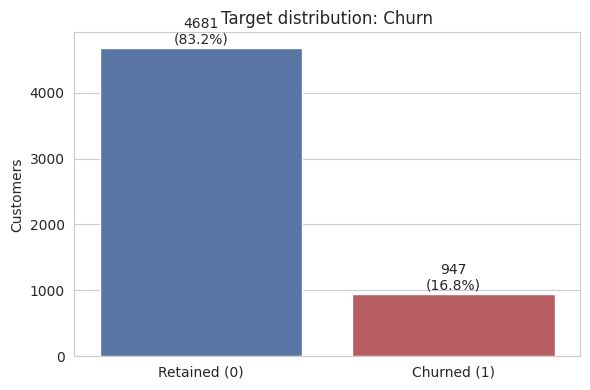

In [14]:
churn_counts = df['Churn'].value_counts().sort_index()
churn_pct = df['Churn'].value_counts(normalize=True).sort_index() * 100

print(churn_counts)
print(churn_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Retained (0)', 'Churned (1)'], y=churn_counts.values,
            palette=['#4C72B0', '#C44E52'], ax=ax)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 60, f"{v}\n({churn_pct.iloc[i]:.1f}%)", ha='center')
ax.set_title('Target distribution: Churn')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.show()


The dataset is **clearly skewed towards non-churners**: about **83% of customers are retained** and only **17% have churned**.

1. **Accuracy is misleading**. A naive model that always predicts "no churn" would still score 83% accuracy while being useless. I therefore evaluate models on **F1**, **Recall** and **Lift**.
2. **Recall on the churner class matters more than Precision**. A false negative (a churner I fail to flag) costs a lost customer, while a false positive (a loyal customer wrongly flagged) only costs the marginal price of a retention offer.


## B.2 Complain and SatisfactionScore vs Churn

These are the two most direct customer-experience signals in the dataset. I expect both to be strong churn drivers.


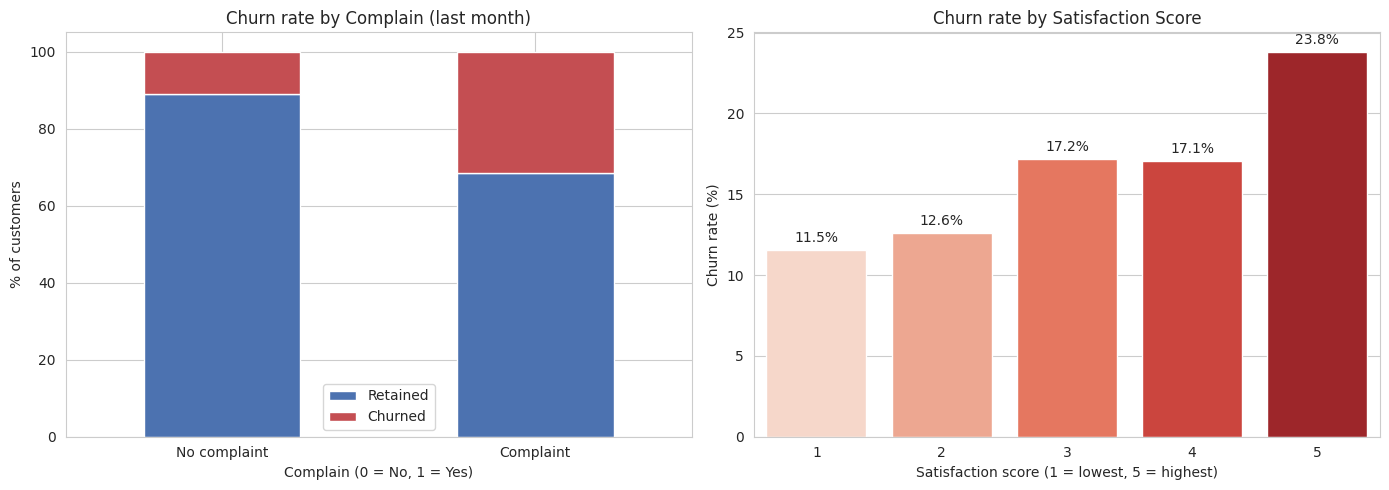

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

complain_churn = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100
complain_churn.plot(kind='bar', stacked=True,
                    color=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Churn rate by Complain (last month)')
axes[0].set_xlabel('Complain (0 = No, 1 = Yes)')
axes[0].set_ylabel('% of customers')
axes[0].legend(['Retained', 'Churned'])
axes[0].set_xticklabels(['No complaint', 'Complaint'], rotation=0)

sat_churn = df.groupby('SatisfactionScore')['Churn'].mean() * 100
sns.barplot(x=sat_churn.index, y=sat_churn.values, palette='Reds', ax=axes[1])
axes[1].set_title('Churn rate by Satisfaction Score')
axes[1].set_xlabel('Satisfaction score (1 = lowest, 5 = highest)')
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(sat_churn.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


In [16]:
corr_target = df[['Complain', 'SatisfactionScore', 'Tenure',
                  'DaySinceLastOrder', 'Churn']].corr()['Churn'].drop('Churn')
corr_target.sort_values(ascending=False)


,Churn
Complain,0.249915
SatisfactionScore,0.105168
DaySinceLastOrder,-0.155937
Tenure,-0.337696


**Reading the charts.**

- **Complain.** Among customers who filed a complaint in the last month, the churn rate jumps to roughly 32%, against 11% for customers without complaints - almost a 3x increase.
- **SatisfactionScore**. Counter-intuitively, the relationship is monotonically increasing: customers giving the top score (5) churn at 23.8%, more than double the rate of customers giving the bottom score (11.5%)
- The two strongest predictors pull in opposite directions: a long customer relationship protects against churn, while a recent complaint accelerates it.


## B.3 Tenure and DaySinceLastOrder vs Churn


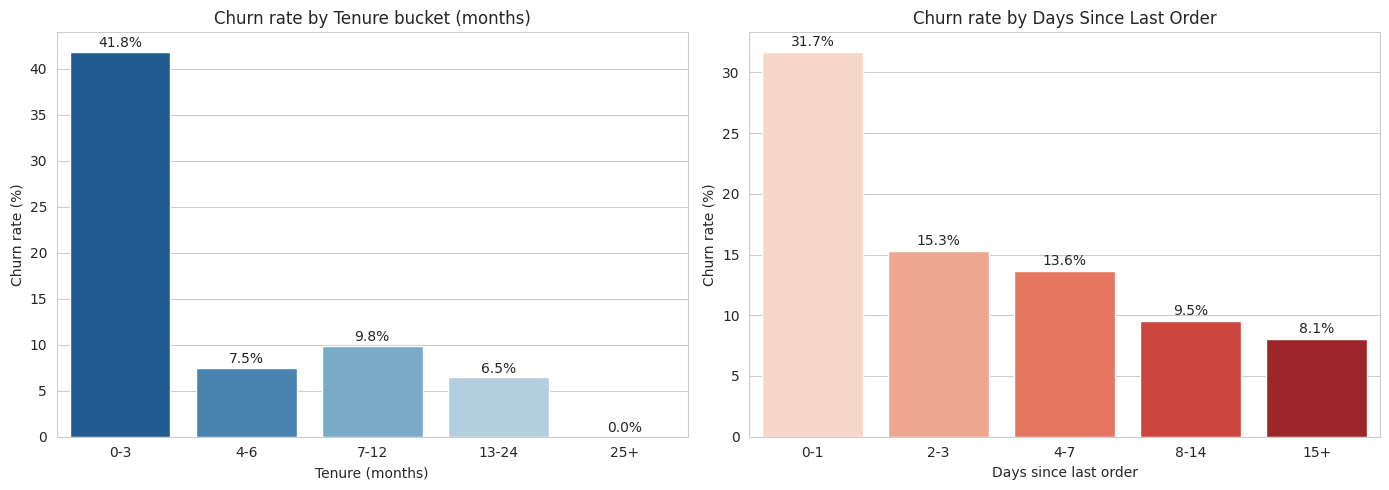

In [17]:
df_eda = df.copy()
df_eda['Tenure_bin'] = pd.cut(
    df_eda['Tenure'],
    bins=[-0.1, 3, 6, 12, 24, df_eda['Tenure'].max()],
    labels=['0-3', '4-6', '7-12', '13-24', '25+']
)
df_eda['DaySinceLastOrder_bin'] = pd.cut(
    df_eda['DaySinceLastOrder'],
    bins=[-0.1, 1, 3, 7, 14, df_eda['DaySinceLastOrder'].max()],
    labels=['0-1', '2-3', '4-7', '8-14', '15+']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tenure_churn = df_eda.groupby('Tenure_bin')['Churn'].mean() * 100
sns.barplot(x=tenure_churn.index, y=tenure_churn.values,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Churn rate by Tenure bucket (months)')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Churn rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha='center')

dslo_churn = df_eda.groupby('DaySinceLastOrder_bin')['Churn'].mean() * 100
sns.barplot(x=dslo_churn.index, y=dslo_churn.values,
            palette='Reds', ax=axes[1])
axes[1].set_title('Churn rate by Days Since Last Order')
axes[1].set_xlabel('Days since last order')
axes[1].set_ylabel('Churn rate (%)')
for i, v in enumerate(dslo_churn.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


**Reading the charts.**

- **Tenure** has a strong protective effect. New customers (0–3 months) churn at 41.8%, while customers with more than two years of relationship essentially do not churn at all (6.5% in the 13–24 month bucket, 0.0% beyond 25 months). The drop is dramatic and happens immediately after the first 3 months. The first three months are the riskiest window by far, and most retention investment should be concentrated there.
- **DaySinceLastOrder** is, paradoxically, negatively correlated with churn in this dataset. Customers who ordered very recently (0–1 day) churn the most (31.7%), while those whose last order is more than 8 days old churn the least (9.5% at 8–14 days, 8.1% at 15+ days). One plausible explanation is that customers about to leave often place a final order shortly before cancelling, which compresses their "days since last order" to near zero. Another possible explanation is that established loyal customers buy less often but more reliably, while erratic high-frequency buyers are the most volatile segment.


---
# Task C. Modeling & Evaluation

Evaluation focuses on **Recall** (catching potential churners), **F1** (balanced view) and **Lift at the top decile** (a marketing-friendly metric measuring how much better the model is than random targeting).


## C.1 Train / test split

I stratify on `Churn` to preserve the class proportions on both sides of the split.


In [18]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape} - churn rate: {y_train.mean():.3f}")
print(f"Test : {X_test.shape} - churn rate: {y_test.mean():.3f}")


Train: (4502, 26) - churn rate: 0.168
Test : (1126, 26) - churn rate: 0.168


I standardise the features for Logistic Regression (which is sensitive to feature scale). Random Forest is invariant to monotonic feature transformations, so I feed the unscaled features to it.


In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


## C.3 Logistic Regression

I pass `class_weight='balanced'` so the optimiser automatically reweights the minority churner class and does not collapse to "predict 0 always".


In [20]:
logreg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
logreg.fit(X_train_sc, y_train)

y_pred_lr = logreg.predict(X_test_sc)
y_proba_lr = logreg.predict_proba(X_test_sc)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))


              precision    recall  f1-score   support

    Retained       0.96      0.77      0.85       937
     Churned       0.43      0.84      0.56       189

    accuracy                           0.78      1126
   macro avg       0.69      0.81      0.71      1126
weighted avg       0.87      0.78      0.81      1126



## C.4 Random Forest

In [21]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))


              precision    recall  f1-score   support

    Retained       0.99      0.98      0.98       937
     Churned       0.92      0.93      0.92       189

    accuracy                           0.97      1126
   macro avg       0.95      0.95      0.95      1126
weighted avg       0.97      0.97      0.97      1126



## C.5 Confusion matrices side by side

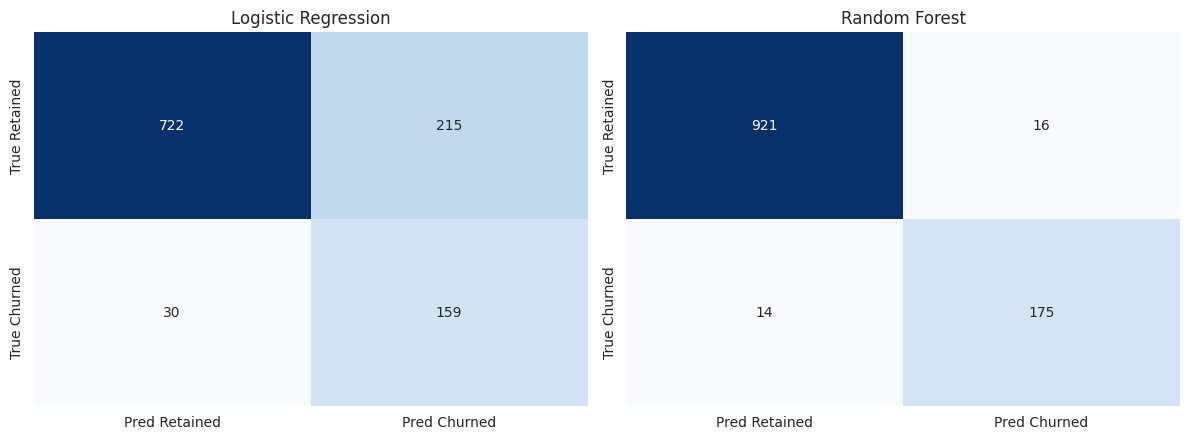

In [22]:
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Retained', 'Pred Churned'],
                yticklabels=['True Retained', 'True Churned'], ax=ax,
                cbar=False)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_cm(y_test, y_pred_lr, 'Logistic Regression', axes[0])
plot_cm(y_test, y_pred_rf, 'Random Forest', axes[1])
plt.tight_layout()
plt.show()


## C.6 Lift at the top decile

Lift answers the marketer's question: *if we send a retention campaign to the top 10% of customers ranked by predicted churn probability, how many more churners do we catch compared to picking 10% at random?*


In [23]:
def lift_at_top_k(y_true, y_proba, k=0.10):
    df_lift = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_proba)})
    df_lift = df_lift.sort_values('p', ascending=False).reset_index(drop=True)
    n_top = int(np.ceil(len(df_lift) * k))
    top_rate = df_lift.iloc[:n_top]['y'].mean()
    base_rate = df_lift['y'].mean()
    return top_rate / base_rate, top_rate, base_rate

lift_lr, top_lr, base_lr = lift_at_top_k(y_test, y_proba_lr, k=0.10)
lift_rf, top_rf, base_rf = lift_at_top_k(y_test, y_proba_rf, k=0.10)

print(f"Baseline churn rate in the test set: {base_lr*100:.2f}%")
print(f"Logistic Regression - top-10% churn rate: {top_lr*100:.2f}% - Lift: {lift_lr:.2f}x")
print(f"Random Forest       - top-10% churn rate: {top_rf*100:.2f}% - Lift: {lift_rf:.2f}x")


Baseline churn rate in the test set: 16.79%
Logistic Regression - top-10% churn rate: 78.76% - Lift: 4.69x
Random Forest       - top-10% churn rate: 100.00% - Lift: 5.96x


## C.7 Model comparison

In [24]:
def summarize(name, y_true, y_pred, y_proba):
    lift, _, _ = lift_at_top_k(y_true, y_proba, k=0.10)
    return {
        'Model': name,
        'Precision (churn)': precision_score(y_true, y_pred),
        'Recall (churn)': recall_score(y_true, y_pred),
        'F1 (churn)': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'Lift @ top 10%': lift
    }

results = pd.DataFrame([
    summarize('Logistic Regression', y_test, y_pred_lr, y_proba_lr),
    summarize('Random Forest', y_test, y_pred_rf, y_proba_rf),
]).set_index('Model').round(3)
results


,Precision (churn),Recall (churn),F1 (churn),ROC-AUC,Lift @ top 10%
Model,,,,,
Logistic Regression,0.425,0.841,0.565,0.883,4.692
Random Forest,0.916,0.926,0.921,0.995,5.958


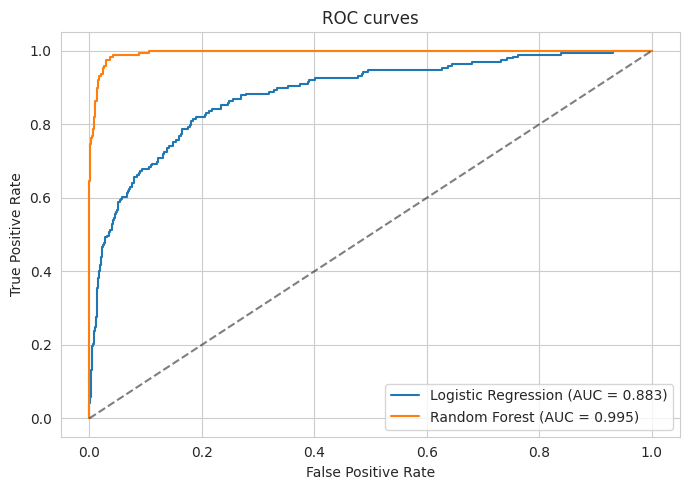

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, y_proba in [('Logistic Regression', y_proba_lr),
                     ('Random Forest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves')
ax.legend()
plt.tight_layout()
plt.show()


## C.8 Why Recall matters more than Precision here

- A **false negative** (the model says "Retained" but the customer actually churns) means we **miss the chance to act**. We lose the entire residual lifetime value of that customer.
- A **false positive** (the model says "Churned" but the customer is loyal) means we **send a retention offer to someone who would have stayed anyway**. The cost is the marginal cost of the offer (a coupon, an email, a discount).

Retaining a customer is worth far more than the price of one unnecessary coupon. We therefore prefer the model with the **higher Recall on the churner class**, even if Precision is slightly lower, and we evaluate campaign efficiency through **Lift**.

## C.9 Top churn drivers (Random Forest feature importances)

This I do for presentation


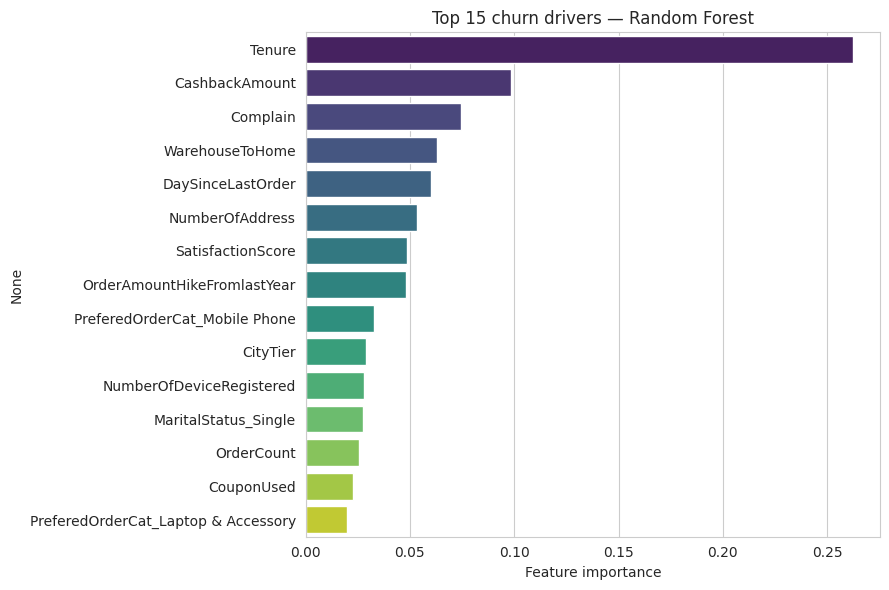

,0
Tenure,0.2622
CashbackAmount,0.0984
Complain,0.0746
WarehouseToHome,0.0629
DaySinceLastOrder,0.0602
NumberOfAddress,0.0535
SatisfactionScore,0.0485
OrderAmountHikeFromlastYear,0.0480
PreferedOrderCat_Mobile Phone,0.0330
CityTier,0.0288


In [26]:
importances = pd.Series(rf.feature_importances_, index=X.columns)\
    .sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index,
            palette='viridis', ax=ax)
ax.set_title('Top 15 churn drivers — Random Forest')
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

importances.head(10).round(4)
